# K-Means Clustering — Method & Analysis

## What K-Means Actually Does
K-Means partitions data into `k` groups by alternating two steps until nothing changes:
1. **Assign** every point to its nearest centroid (by Euclidean distance).
2. **Update** each centroid to the mean of the points just assigned to it.

Repeat until assignments stop changing (or a max iteration count is hit). The only thing K-Means is ever doing under the hood is minimizing **inertia** — the total squared distance from every point to its own cluster's centroid. It has no concept of "topic" or "meaning"; it is pure geometry over whatever numeric features it's handed. Two things follow directly from that:
- **The features have to already be numeric and meaningful** before K-Means can do anything useful with them. This notebook does not build those features — it loads a ready-made numeric feature matrix from `text_feature_engineering.ipynb` (TF-IDF -> LSA on real complaint-topic text) and treats *that* as the input. How the numbers were built matters, but it's a separate concern from what this notebook is about.
- **`k` has to be chosen before fitting**, and K-Means will happily produce a "clean-looking" answer for the wrong `k` — it has no way to tell you it's wrong. Section 2 below covers choosing `k` from the data itself, without peeking at ground truth.

## Objective
Given a real, pre-engineered feature matrix, this notebook demonstrates the actual K-Means workflow end to end: choosing `k`, fitting, and then critically evaluating what the algorithm found — where it agrees with the true structure, where it doesn't, and why, using standard cluster-validation methods (elbow, silhouette, Adjusted Rand Index, Normalized Mutual Information) rather than eyeballing a scatter plot.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

DATA_DIR = "../data"
RESULT_DIR = "../result"
RANDOM_STATE = 42

## 1. Load the Pre-Engineered Features

`text_feature_engineering.ipynb` already turned 6,630 real, unlabeled complaint-topic posts (20 Newsgroups, reframed — see that notebook for the full data story) into a 100-dimensional numeric feature matrix via TF-IDF + LSA, and saved both the feature matrix and the fitted vectorizer/SVD objects. This notebook starts from that output.

In [2]:
features_df = pd.read_parquet(f"{DATA_DIR}/complaint_lsa_features.parquet")

lsa_cols = [c for c in features_df.columns if c.startswith("lsa_")]
X = features_df[lsa_cols].to_numpy()
true_labels = features_df["true_label"].to_numpy()
true_label_names = features_df["true_label_name"].tolist()

pipeline = joblib.load(f"{DATA_DIR}/complaint_feature_pipeline.joblib")
vectorizer, svd, CATEGORY_LABELS, categories = (
    pipeline["vectorizer"], pipeline["svd"], pipeline["category_labels"], pipeline["categories"]
)

print(f"Feature matrix: {X.shape[0]} documents x {X.shape[1]} dimensions")
pd.Series(true_label_names).value_counts()

Feature matrix: 6630 documents x 100 dimensions


PC Hardware               961
Health/Medical Product    958
Automotive                955
Billing/Marketplace       955
Electronics Product       954
Motorcycle/Vehicle        926
Mac Hardware              921
Name: count, dtype: int64

## 2. Choosing k — Elbow & Silhouette (without looking at the true labels)

In a real operational setting there's no ground truth to check against — `k` has to be estimated from the data itself.

- **Elbow method** — plots inertia (total within-cluster squared distance) against `k`. Inertia always decreases as `k` grows (more clusters can only fit the data at least as well), so the question isn't "which k is lowest" but "where do the returns stop being worth it" — the point where the curve bends from steep to shallow.
- **Silhouette method** — for each point, compares its average distance to points in its own cluster against its average distance to points in the *nearest other* cluster, averaged across all points. Ranges -1 to 1; higher means clusters are both internally tight and well-separated from each other, which inertia alone can't tell you.

The green line marks the actual number of categories (7) purely so the chart can be sanity-checked against it after the fact — it is not used to pick k below.

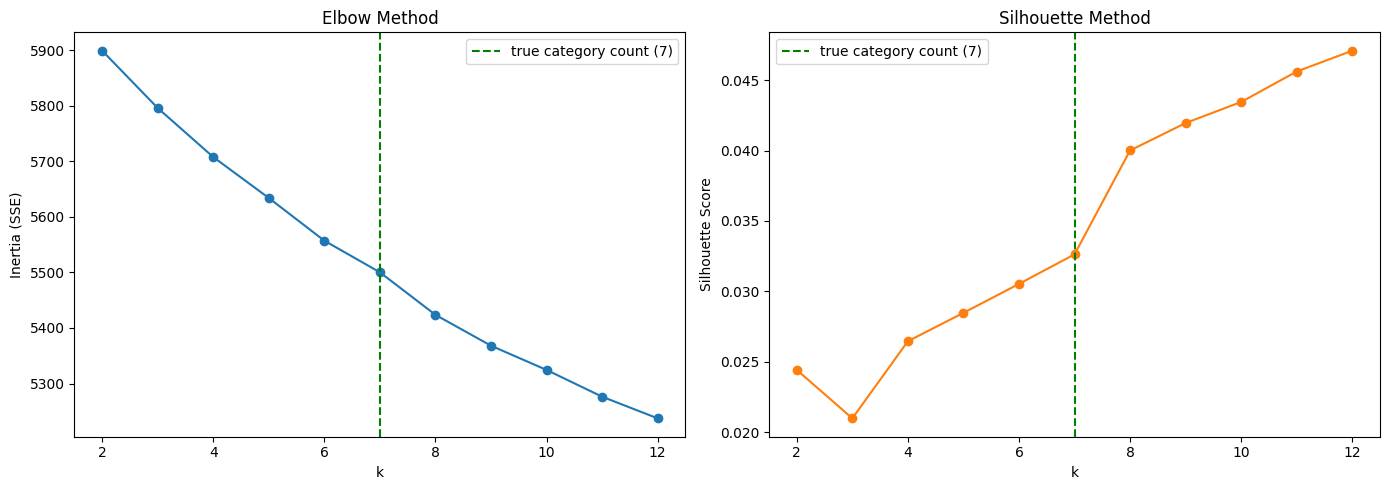

In [3]:
k_range = range(2, 13)
sse, sil_scores = [], []

for k in k_range:
    km_probe = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_probe = km_probe.fit_predict(X)
    sse.append(km_probe.inertia_)
    sil_scores.append(silhouette_score(X, labels_probe))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), sse, marker='o')
axes[0].axvline(len(categories), color='green', linestyle='--', label=f'true category count ({len(categories)})')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia (SSE)'); axes[0].set_title('Elbow Method')
axes[0].legend()

axes[1].plot(list(k_range), sil_scores, marker='o', color='tab:orange')
axes[1].axvline(len(categories), color='green', linestyle='--', label=f'true category count ({len(categories)})')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette Score'); axes[1].set_title('Silhouette Method')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{RESULT_DIR}/elbow_and_silhouette.png', dpi=150)
plt.show()

## 3. Fit K-Means at k = 7 and Score Against the True Categories

Now the true labels get used — but only to *evaluate* the fitted model, never to fit it. Two standard clustering-agreement metrics, both scaled 0 (random) to 1 (perfect match), and both correct for chance agreement (unlike raw accuracy, which K-Means can't even compute anyway since its cluster numbers are arbitrary and don't align to label order):
- **Adjusted Rand Index (ARI)** — agreement on pairs of documents (same cluster and same true category, or different cluster and different category).
- **Normalized Mutual Information (NMI)** — how much knowing a document's cluster reduces uncertainty about its true category.

In [4]:
K = len(categories)
km = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=10)
pred_labels = km.fit_predict(X)

ari = adjusted_rand_score(true_labels, pred_labels)
nmi = normalized_mutual_info_score(true_labels, pred_labels)
print(f"Adjusted Rand Index    : {ari:.3f}")
print(f"Normalized Mutual Info : {nmi:.3f}")

Adjusted Rand Index    : 0.291
Normalized Mutual Info : 0.391


## 4. Cluster vs. True Category — Confusion Heatmap

Even a strong ARI/NMI number hides *where* the confusion is. This heatmap shows whether each cluster maps cleanly onto one category or blends several — and if it blends, which ones (a real ops team would read this exact chart to decide whether two categories need to be merged, split, or handled with extra care downstream).

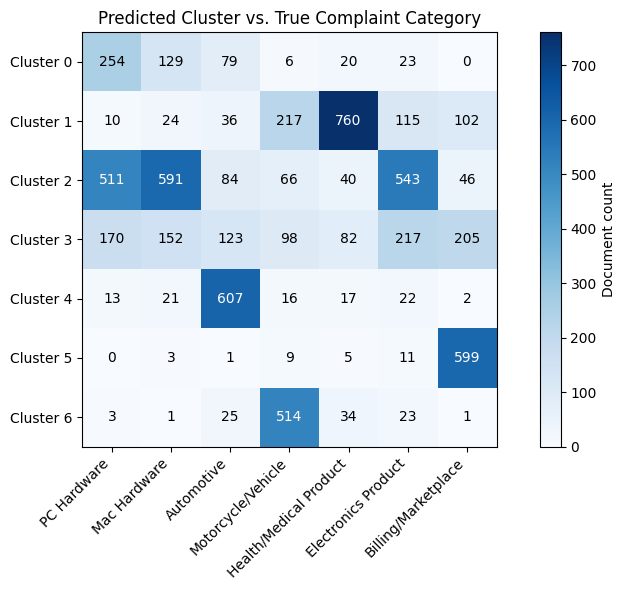

In [5]:
ct = pd.crosstab(pd.Series(pred_labels, name='Cluster'), pd.Series(true_label_names, name='True Category'))
ct = ct[[CATEGORY_LABELS[c] for c in categories]]  # keep column order consistent with the table above

fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(ct.values, cmap='Blues')
ax.set_xticks(range(len(ct.columns))); ax.set_xticklabels(ct.columns, rotation=45, ha='right')
ax.set_yticks(range(len(ct.index))); ax.set_yticklabels([f'Cluster {i}' for i in ct.index])
for i in range(ct.shape[0]):
    for j in range(ct.shape[1]):
        val = ct.values[i, j]
        ax.text(j, i, val, ha='center', va='center',
                 color='white' if val > ct.values.max() / 2 else 'black')
ax.set_title('Predicted Cluster vs. True Complaint Category')
fig.colorbar(im, ax=ax, label='Document count')
plt.tight_layout()
plt.savefig(f'{RESULT_DIR}/cluster_vs_category_heatmap.png', dpi=150)
plt.show()

## 5. What Does Each Cluster Actually Represent? Top Terms per Cluster

In a real ops setting nobody hands you labels — this is how you'd actually name an auto-discovered segment: read the terms closest to its centroid. `svd.inverse_transform` (loaded from the feature-engineering notebook's saved pipeline) maps each LSA-space cluster centroid back to the original TF-IDF term space so the raw vocabulary can be read off directly — this step is the one place this notebook reaches back into the vectorizer, purely to interpret a result, not to build a feature.

In [6]:
terms = np.array(vectorizer.get_feature_names_out())
original_space_centroids = svd.inverse_transform(km.cluster_centers_)
order_centroids = original_space_centroids.argsort()[:, ::-1]

top_terms_rows = []
for i in range(K):
    top_terms = terms[order_centroids[i, :10]]
    top_terms_rows.append({
        "Cluster": i,
        "Size": int((pred_labels == i).sum()),
        "Top terms": ", ".join(top_terms),
    })

top_terms_df = pd.DataFrame(top_terms_rows)
top_terms_df

,Cluster,Size,Top terms
0,0,511,"drive, scsi, hard, drives, disk, ide, controll..."
1,1,1264,"bike, right, ride, way, people, dod, riding, t..."
2,2,1881,"use, card, problem, monitor, used, using, appl..."
3,3,1047,"thanks, edu, mail, information, looking, advan..."
4,4,698,"sale, offer, shipping, 00, condition, new, int..."
5,5,628,"people, doctor, disease, medical, cause, treat..."
6,6,601,"car, cars, engine, new, ford, miles, oil, deal..."


## 6. 2D View — Predicted Clusters vs. True Categories, Side by Side

Only 2 of the feature matrix's 100 dimensions can be plotted directly, so this is a rough sanity check rather than the real evidence (that's the ARI/NMI and heatmap above) — but it's still informative to see how much structure survives such a narrow slice.

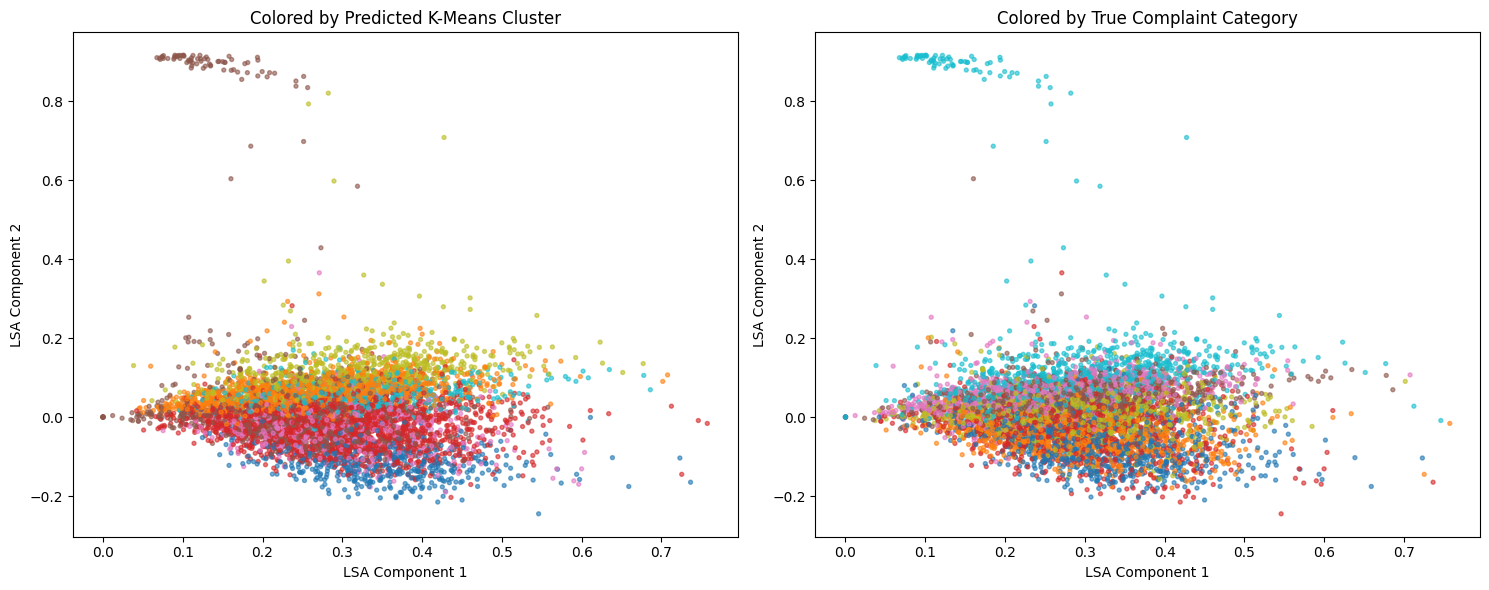

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].scatter(X[:, 0], X[:, 1], c=pred_labels, cmap='tab10', s=8, alpha=0.6)
axes[0].set_title('Colored by Predicted K-Means Cluster')
axes[0].set_xlabel('LSA Component 1'); axes[0].set_ylabel('LSA Component 2')

axes[1].scatter(X[:, 0], X[:, 1], c=true_labels, cmap='tab10', s=8, alpha=0.6)
axes[1].set_title('Colored by True Complaint Category')
axes[1].set_xlabel('LSA Component 1'); axes[1].set_ylabel('LSA Component 2')

plt.tight_layout()
plt.savefig(f'{RESULT_DIR}/lsa_2d_clusters_vs_categories.png', dpi=150)
plt.show()

## Conclusion

**Results** (see the printed cells and charts above): ARI = 0.29, NMI = 0.39 on 6,630 real, unlabeled posts across 7 categories — clearly and substantially above the ARI = 0 / NMI = 0 chance baseline, but well short of a clean 1.0 recovery. That gap is the honest, useful finding here, not a shortcoming to explain away: five of the seven categories (Billing/Marketplace, Motorcycle/Vehicle, Health/Medical, PC Hardware, Automotive) map onto a cluster cleanly enough to name from its top terms alone; Mac Hardware and Electronics Product blend into two larger, vaguer clusters — the confusion heatmap shows exactly where, and the two categories genuinely do share a lot of tech-support vocabulary ("card", "drive", "mail"...) that the underlying features can't fully disentangle.

**Operational read:** with zero manually-labeled examples, K-Means recovers most of the real topic structure directly from the engineered features, well enough to pre-sort the bulk of incoming volume and cut manual triage load — but it is not accurate enough on its own to fully automate routing for categories that overlap this much in vocabulary. That's the same conclusion an operations team would need to reach: unsupervised clustering is a strong first-pass triage layer, not a drop-in replacement for a routing rule (or human) on the categories it can't cleanly separate. The top-terms-per-cluster table is what makes this usable in practice either way — it lets someone assign a human-readable name to each auto-discovered segment without pre-existing labels, then decide per-cluster whether to trust it or route it for a closer look.